In [1]:
%matplotlib inline
from __future__ import division
import matplotlib
import numpy as np
from pylab import *
from mpl_toolkits.mplot3d import Axes3D
import h5py
import os
matplotlib.rcParams.update({"axes.formatter.limits": (-4,4)})
plotStyles={"markersize":12,"markeredgewidth":3.0,"linewidth":3.0}
stepStyles={"markersize":12,"markeredgewidth":3.0,"linewidth":3.0,"where":"post"}
np.seterr(divide='ignore',invalid='ignore')
pass

In [2]:
# Setup plot styles for saving figures.
def figure_style():
    global plotStyles,stepStyles
    matplotlib.rcParams.update({"axes.formatter.limits": (-4,4), "svg.fonttype" : "none", 'pdf.fonttype':42,'font.family':'sans-serif','font.sans-serif':'Helvetica','font.size': 9, "axes.titlesize": 10, "xtick.labelsize": 8, "ytick.labelsize": 8,'text.usetex':True,'text.latex.preamble':[r'\usepackage{sansmath}',r'\sansmath']})
    plotStyles={"markersize":4,"markeredgewidth":1.0,"linewidth":1.0}
    stepStyles={"markersize":20,"markeredgewidth":3.0,"linewidth":3.0,"where":"post"}

In [3]:
# Setup plot styles for on-screen plotting.
def screen_style(fontSize=20):
    global plotStyles,stepStyles
    matplotlib.rcParams.update({"axes.formatter.limits": (-4,4), "svg.fonttype" : "none", 'pdf.fonttype':42,'font.family':'sans-serif','font.sans-serif':'Helvetica','font.size': fontSize, "axes.titlesize": fontSize, "xtick.labelsize": fontSize, "ytick.labelsize": fontSize,'text.usetex':True,'text.latex.preamble':[r'\usepackage{sansmath}',r'\sansmath']})
    plotStyles={"markersize":12,"markeredgewidth":3.0,"linewidth":3.0}
    stepStyles={"markersize":20,"markeredgewidth":3.0,"linewidth":3.0,"where":"post"}

In [4]:
%%javascript
IPython.OutputArea.auto_scroll_threshold = 9999;

<IPython.core.display.Javascript object>

# Regression tests for a set of sources and sinks.

### Execute a simulation with eight sources and eight sinks.

In [165]:
%%bash
dirname=data/1
filename=${dirname}/microenv_source_sink.lm
sfilename=${dirname}/microenv_source_sink.sfile
mkdir -p ${dirname}
rm -f ${filename} && lm_sbml_import ${filename} microenv_source_sink.sbml
lm_setp ${filename} writeInterval=1e-1 maxTime=1e1
rm -f ${sfilename}
echo "Execute the following command in `pwd`:"
echo "lmes -me -f ${filename} -gr 0 -c 3 -r 0 -ff sfile -fo ${sfilename}"


lm_sbml_import v2016.05.10 build 1
Copyright (C) 2008-2012 Luthey-Schulten Group, University of Illinois at Urbana-Champaign.
Copyright (C) 2012-2016 Roberts Group, Johns Hopkins University.


2016-05-16 14:39:26) Processing 1 compartments.
2016-05-16 14:39:26) Added compartment (0) V: 3.350000e-14
2016-05-16 14:39:26) Processing 3 species.
2016-05-16 14:39:26) Added species (0) E with initial count: 0
2016-05-16 14:39:26) Added species (1) SOURCE with initial count: 0
2016-05-16 14:39:26) Added species (2) SINK with initial count: 0
2016-05-16 14:39:26) Processing 2 reactions.
2016-05-16 14:39:26) Matched kinetic formula in reaction (0)  to FirstOrderPropensity: [20000 * SOURCE] == [k1 * x1]
2016-05-16 14:39:26) Matched kinetic formula in reaction (1)  to SecondOrderPropensity: [20000 * SINK * E] == [k1 * x1 * x2]
2016-05-16 14:39:26) There output file was successfully genereated.
lm_setp v2016.01.20 build 1
Copyright (C) 2008-2012 Luthey-Schulten Group,
University of Illinois at Urba

### Loop through the output file to get some sizes.

In [166]:
import re
from robertslab import ndarray
from robertslab.sfile import SFile
import lm.io.ConcentrationsTimeSeries_pb2 as cts
import lm.io.SpeciesTimeSeries_pb2 as sts

# Set the filename.
dirname="data/1"
filename="%s/microenv_source_sink.sfile"%dirname

# Get some statistics
numberTimes=0
gridShape=None
gridSpacing=4e-6
NA=6.02e23
numberCells=0
numberSpecies=None
file=SFile.fromFilename(filename, "r")
while True:
    record=file.readNextRecord()
    if record is None: break
    if record.dataType == "protobuf:lm.io.ConcentrationsTimeSeries":
        obj=cts.ConcentrationsTimeSeries()
        obj.ParseFromString(file.readData(record.dataSize))
        numberTimes += obj.times.shape[0]
        if gridShape is None: gridShape = tuple(obj.concentrations[0].shape)
    elif record.dataType == "protobuf:lm.io.SpeciesTimeSeries":
        obj=sts.SpeciesTimeSeries()
        obj.ParseFromString(file.readData(record.dataSize))
        cell = obj.trajectory_id
        numberCells=max(cell+1,numberCells)
        if numberSpecies is None: numberSpecies = obj.counts.shape[1]
    else:
        file.skipData(record.dataSize)
file.close();
numberCells = len(cells)
print "Finished processing, number of time points was: ",numberTimes,", grid shape was: ",gridShape,", number of cells was: ",numberCells,", number of species was: ",numberSpecies

Finished processing, number of time points was:  101 , grid shape was:  (1, 200, 200) , number of cells was:  16 , number of species was:  3


### Load the concentration time series.

In [167]:
# Load the records for this replicate.
times=np.zeros((numberTimes,), dtype=float)
grids=np.zeros((numberTimes,)+gridShape, dtype=float)
file=SFile.fromFilename(filename, "r")
index=0
while True:
    record=file.readNextRecord()
    if record is None: break
    if record.dataType == "protobuf:lm.io.ConcentrationsTimeSeries":
        obj=cts.ConcentrationsTimeSeries()
        obj.ParseFromString(file.readData(record.dataSize))
        recordTimes = ndarray.deserializeMessage(obj.times)
        for j in range(0,recordTimes.shape[0]):
            times[index] = recordTimes[j]
            grids[index,:,:,:] = ndarray.deserializeMessage(obj.concentrations[j])
            index += 1
    else:
        file.skipData(record.dataSize)
file.close();
print "Finished loading."
pass

Finished loading.


### Load the cell time series.

In [168]:
# Load the records for this replicate.
counts=np.zeros((numberTimes,numberCells,numberSpecies))
file=SFile.fromFilename(filename, "r")
index={}
for cell in range(0,numberCells):
    index[cell] = 0
while True:
    record=file.readNextRecord()
    if record is None: break
    elif record.dataType == "protobuf:lm.io.SpeciesTimeSeries":
        obj=sts.SpeciesTimeSeries()
        obj.ParseFromString(file.readData(record.dataSize))
        cell = obj.trajectory_id
        recordCounts = ndarray.deserializeMessage(obj.counts)
        recordTimes = ndarray.deserializeMessage(obj.times)
        for i in range(0,recordCounts.shape[0]):
            if recordTimes[i] != times[index[cell]]: print "Consistency error in cell %d: %e != %e"%(cell,recordTimes[i],times[index[cell]])
            counts[index[cell],cell,:] = recordCounts[i]
            index[cell] += 1
    else:
        file.skipData(record.dataSize)
file.close();
print "Finished loading."
pass

Finished loading.


### Plot the total mass in the diffusion volume as a function of time.

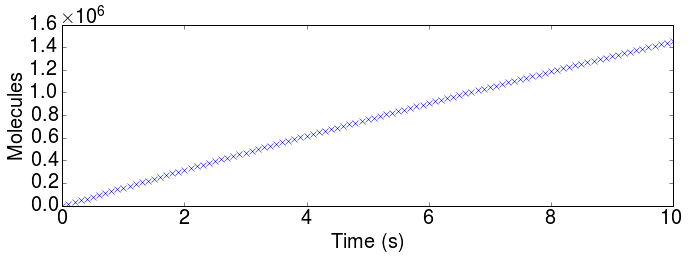

In [169]:
screen_style()
matplotlib.rcParams.update({"figure.figsize": (10,4)})
plotIndex=1
mass=np.sum(grids, (1,2,3))
plot(times, mass*NA*(gridSpacing**3)*1000, 'x')
xlabel("Time (s)"); ylabel("# Molecules");
plt.tight_layout()
pass

### Plot the concentrations at a specific frame of the simulation.

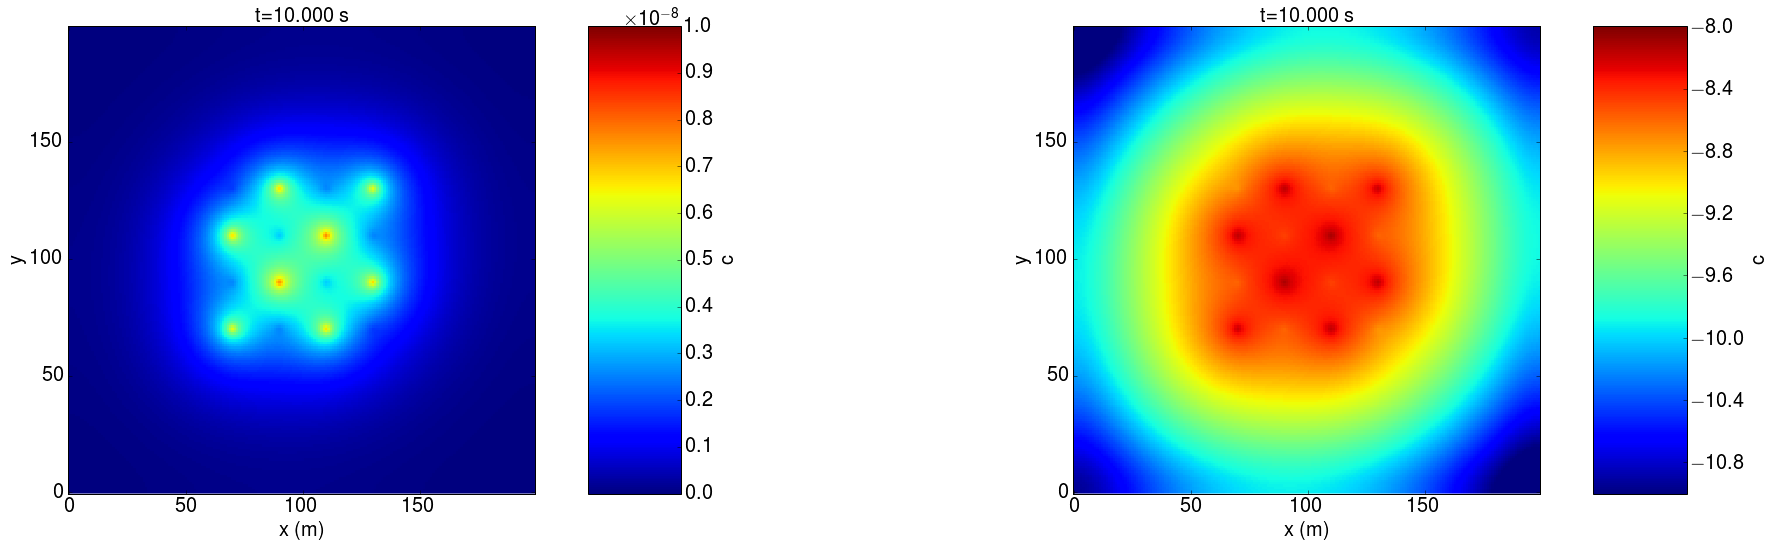

In [186]:
screen_style()
matplotlib.rcParams.update({"figure.figsize": (30,8)})
subplot(1,2,1)
imshow((grids[-1,0,:,:]), interpolation='none', aspect=1, origin='lower', vmin=0, vmax=1e-8)
cb=colorbar(label="c"); cb.ax.set_aspect(5)
xlabel(r"x (m)"); ylabel("y"); title("t=%0.3f s"%times[i])
subplot(1,2,2)
imshow(log10(grids[-1,0,:,:]), interpolation='none', aspect=1, origin='lower', vmin=-11, vmax=-8)
cb=colorbar(label="c"); cb.ax.set_aspect(5)
xlabel(r"x (m)"); ylabel("y"); title("t=%0.3f s"%times[i])
plt.tight_layout()
pass

### Plot the concentration vs time.

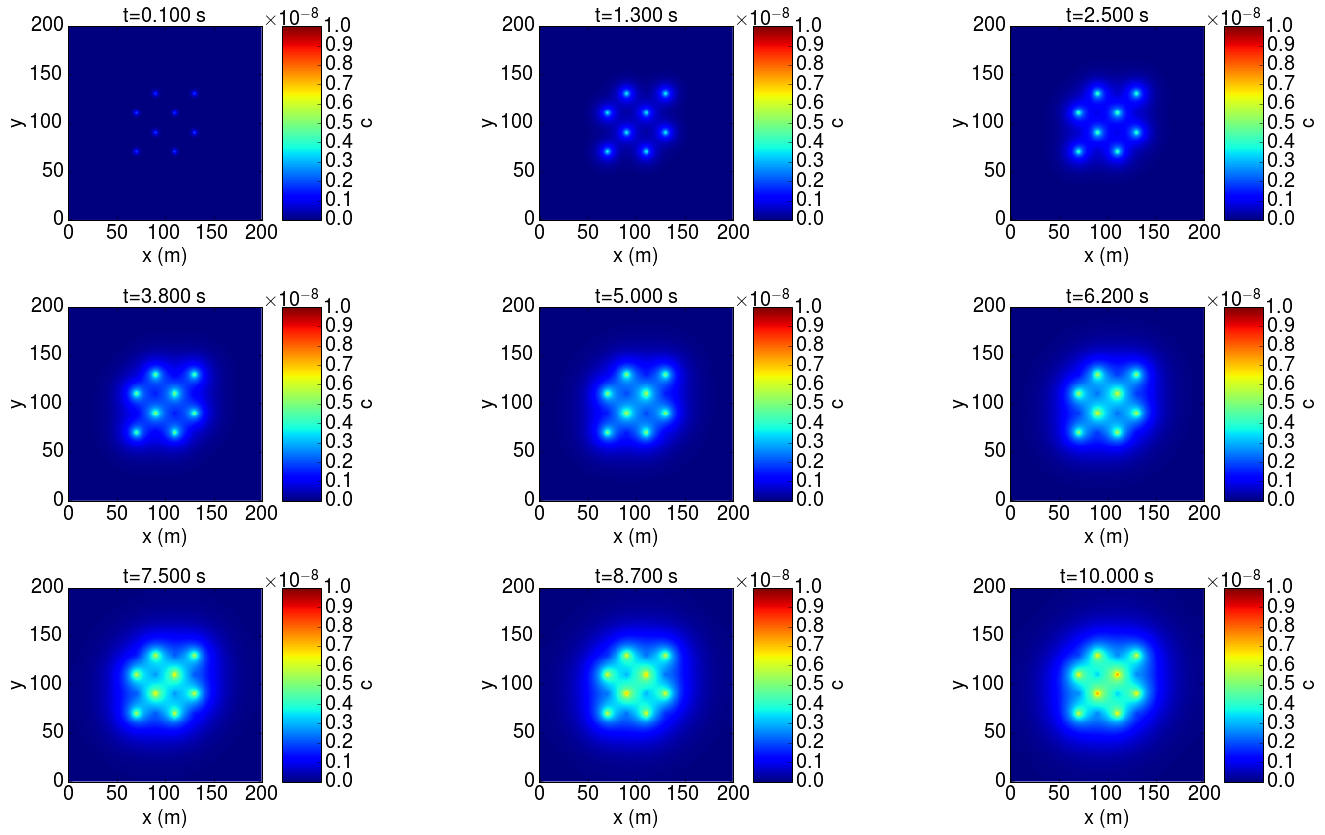

In [179]:
screen_style()
rows=3
cols=3
matplotlib.rcParams.update({"figure.figsize": (20,4*rows)})
plotIndex=1
for plotIndex,i in enumerate(np.linspace(1,times.shape[0]-1,rows*cols, dtype=int)):
    subplot(rows,cols,plotIndex+1)
    #imshow(log10(grids[i,0,:,:]), interpolation='none', aspect=1, origin='lower', vmin=-11, vmax=-8)
    imshow((grids[i,0,:,:]), interpolation='none', aspect=1, origin='lower', vmin=0, vmax=1e-8)
    cb=colorbar(label="c"); cb.ax.set_aspect(5)
    xlabel(r"x (m)"); ylabel("y"); title("t=%0.3f s"%times[i])
plt.tight_layout()
pass

### Plot the cell species counts vs time.

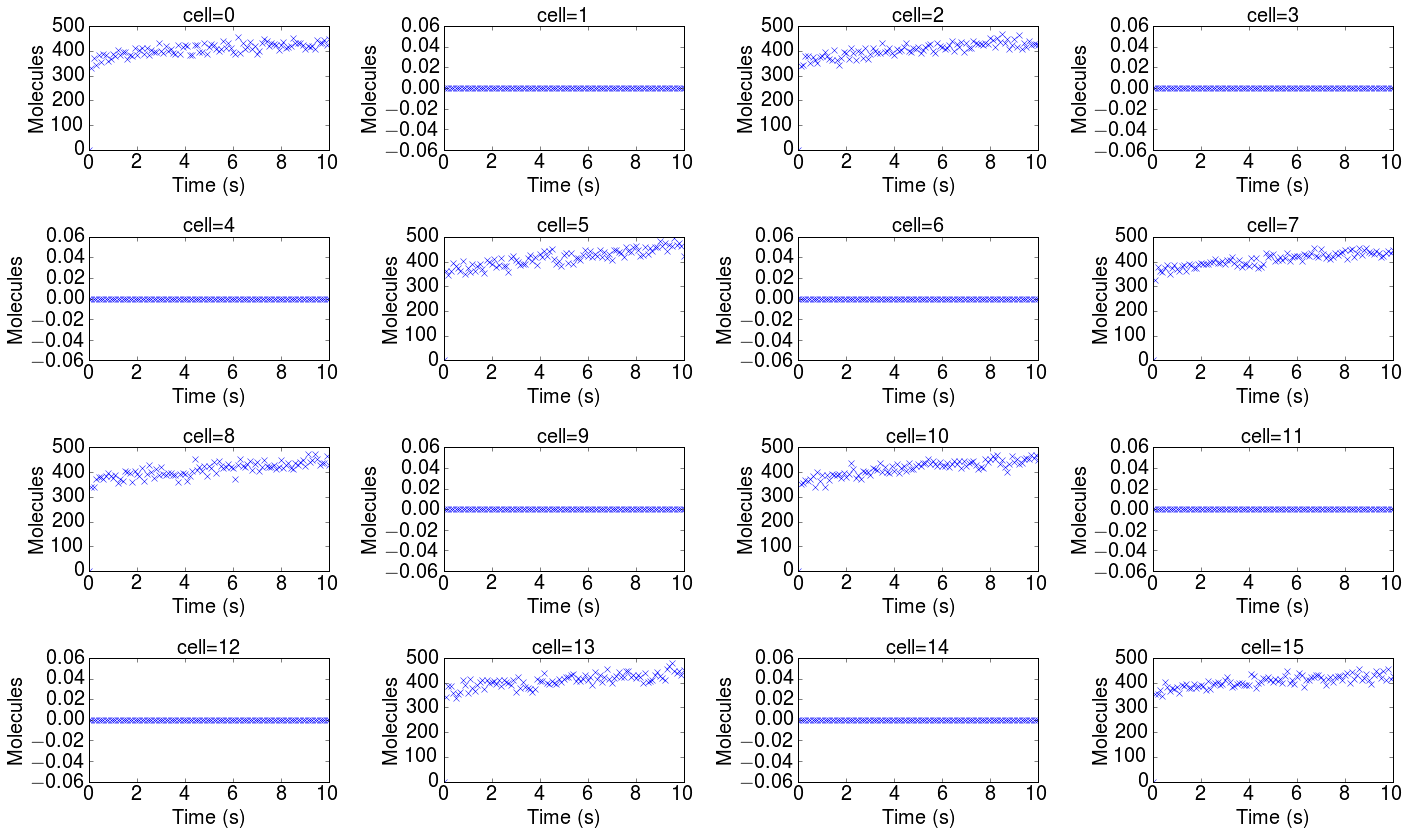

In [172]:
screen_style()
cols=4
rows=ceil(counts.shape[1]/cols)
matplotlib.rcParams.update({"figure.figsize": (20,3*rows)})
for i in range(0,counts.shape[1]):
    subplot(rows,cols,i+1)
    plot(times, counts[:,i,0], 'x')
    xlabel("Time (s)"); ylabel("# Molecules"); title("cell=%d"%i)
plt.tight_layout()
pass